Device: cuda
Reading FEAT_DIM from model config...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FEAT_DIM: 768
NIH CSV : /kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv
NIH images indexed: 112120
Rows with images: 112120  sex: {'M': 63340, 'F': 48780}
Sampled: male=8000 female=3000
Loading CLIP ViT-L/14 (frozen)...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded.

Extracting male features (8000)...
  64/8000
  1344/8000
  2624/8000
  3904/8000
  5184/8000
  6464/8000
  7744/8000
Extracting female features (3000)...
  64/3000
  1344/3000
  2624/3000
male (8000, 768)  female (3000, 768)

=== Female prevalence (nc/Ng) ===
         pathology  nc   Ng  nc_ng
            Hernia  11 3000 0.0037
         Emphysema  40 3000 0.0133
         Pneumonia  42 3000 0.0140
          Fibrosis  49 3000 0.0163
             Edema  65 3000 0.0217
      Cardiomegaly  77 3000 0.0257
Pleural_Thickening  90 3000 0.0300
     Consolidation 112 3000 0.0373
              Mass 130 3000 0.0433
      Pneumothorax 162 3000 0.0540
            Nodule 181 3000 0.0603
       Atelectasis 293 3000 0.0977
          Effusion 377 3000 0.1257
      Infiltration 529 3000 0.1763

Validation targets: ['Hernia', 'Emphysema', 'Pneumonia']

Pathology: Hernia
nc/Ng=0.0037  MAD_risk=0.0004  mu_cosine=0.8978  pred=False
SGG = 0.7026 − 0.7532 = -0.0506
Train 8200 (20 pos) / Test 2800 

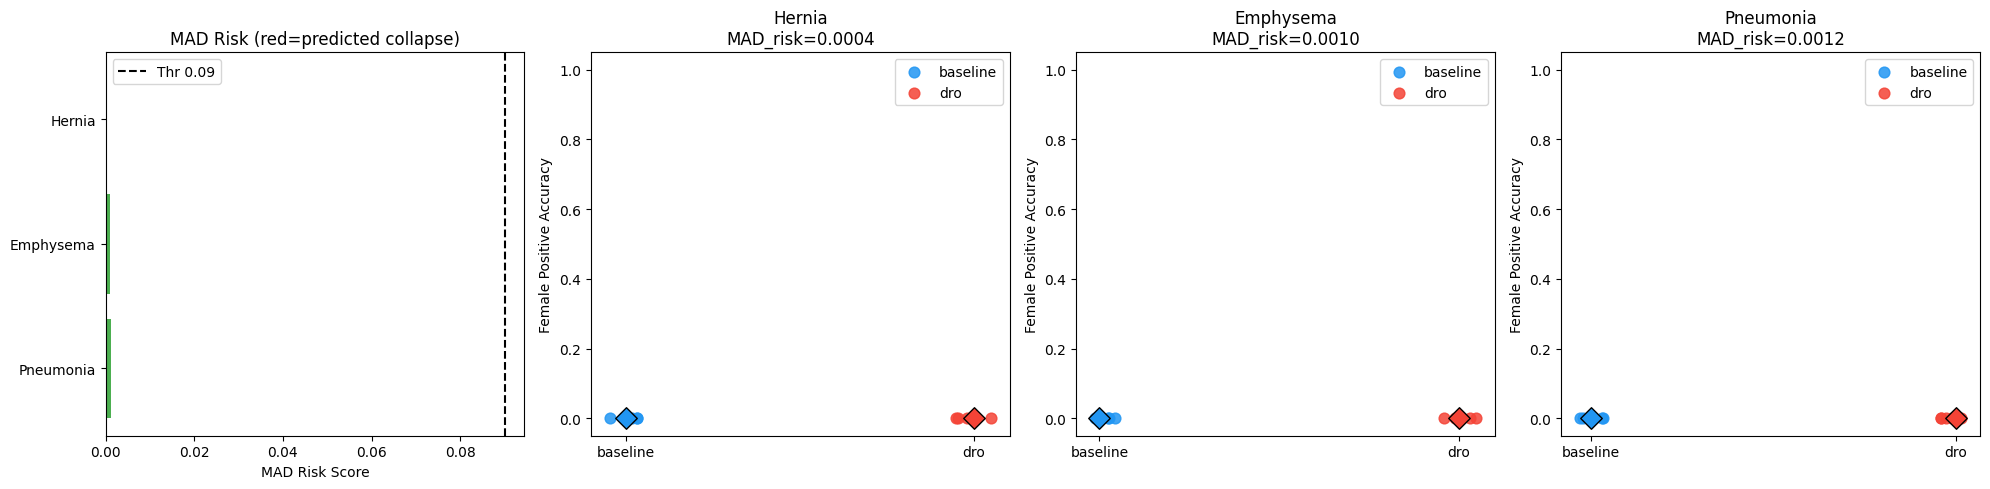


✓ Done. Files: /kaggle/working/nih_mad_risk_scores.csv, /kaggle/working/nih_dro_results.csv, /kaggle/working/nih_weight_traj.json, /kaggle/working/nb_nih_validation_figure.png
Paste ALL output + upload figure to Claude.


In [4]:
# ============================================================
# External Validation: MAD Risk Score — NIH ChestX-ray14
# CLIP ViT-L/14 frozen probe, sex × pathology minority-within-minority
# GPU: T4 x1, Internet ON.  Est. ~2.5 hr.
#
# !! IMPORTANT: Restart kernel before running !!
# ============================================================

import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from transformers import CLIPModel
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── Constants ──────────────────────────────────────────────────
BASE_SEED    = 42
SEEDS        = [42, 0, 1, 7, 99]
N_EPOCHS     = 5
BATCH_SIZE   = 32
LR           = 1e-4
WD           = 1e-4
ETA_DRO      = 0.1
N_GROUPS     = 4
COLLAPSE_THR = 0.01
RISK_THRESH  = 0.09
NC_NG_MAX    = 0.20
MAX_MALE     = 8000
MAX_FEMALE   = 3000
MODEL_ID     = "openai/clip-vit-large-patch14"
MINORITY_G   = 3    # female(1)×2 + positive(1)

# FEAT_DIM: load model once to read visual_projection.out_features, then discard
print("Reading FEAT_DIM from model config...")
_tmp = CLIPModel.from_pretrained(MODEL_ID, torch_dtype=torch.float16)
FEAT_DIM = _tmp.visual_projection.out_features
del _tmp; torch.cuda.empty_cache()
print(f"FEAT_DIM: {FEAT_DIM}")   # expect 768 for ViT-L/14 projection output

# ── NIH dataset discovery ──────────────────────────────────────
_csv = None
for _r, _d, _fs in os.walk("/kaggle/input"):
    for _f in _fs:
        if _f.startswith("Data_Entry") and _f.endswith(".csv"):
            _csv = os.path.join(_r, _f); break
    if _csv: break
nih_csv  = _csv or "/kaggle/input/nih-chest-xrays/Data_Entry_2017.csv"
nih_base = os.path.dirname(nih_csv)
print(f"NIH CSV : {nih_csv}")

img_index = {}
for _r, _d, _fs in os.walk(nih_base):
    for _f in _fs:
        if _f.lower().endswith((".png",".jpg",".jpeg")):
            img_index[_f] = os.path.join(_r, _f)
print(f"NIH images indexed: {len(img_index)}")

df = pd.read_csv(nih_csv)
df["local_path"] = df["Image Index"].map(img_index)
df = df[df["local_path"].notna()].copy()
df["Patient Gender"] = df["Patient Gender"].str.strip().str.upper()
df = df[df["Patient Gender"].isin(["M","F"])].copy()
print(f"Rows with images: {len(df)}  sex: {df['Patient Gender'].value_counts().to_dict()}")

np.random.seed(BASE_SEED)
male_df   = df[df["Patient Gender"]=="M"].sample(min(MAX_MALE,   (df["Patient Gender"]=="M").sum()), random_state=BASE_SEED)
female_df = df[df["Patient Gender"]=="F"].sample(min(MAX_FEMALE, (df["Patient Gender"]=="F").sum()), random_state=BASE_SEED)
print(f"Sampled: male={len(male_df)} female={len(female_df)}")

# ── Load CLIP frozen ───────────────────────────────────────────
print("Loading CLIP ViT-L/14 (frozen)...")
clip_model = CLIPModel.from_pretrained(MODEL_ID, torch_dtype=torch.float16, device_map="auto")
clip_model.eval()
for p in clip_model.parameters():
    p.requires_grad_(False)
print("CLIP loaded.")

MEAN = [0.48145466, 0.4578275,  0.40821073]
STD  = [0.26862954, 0.26130258, 0.27577711]
img_tf = transforms.Compose([transforms.Resize(224), transforms.CenterCrop(224),
                              transforms.ToTensor(), transforms.Normalize(MEAN,STD)])


def clip_feats(model, pixel_values):
    """Safely extract L2-normalised float32 embeddings from CLIP.
    Handles both Tensor and BaseModelOutputWithPooling returns."""
    out = model.get_image_features(pixel_values=pixel_values)
    if not isinstance(out, torch.Tensor):
        out = out.image_embeds if hasattr(out, "image_embeds") else out.pooler_output
    out = out.float()
    return out / out.norm(dim=-1, keepdim=True)

def wilson_ci(k, n, z=1.96):
    if n == 0: return (0.0, 0.0)
    p = k / n
    denom  = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denom
    margin = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))

def init_group_weights(n_groups, device):
    return torch.ones(n_groups, device=device) / n_groups

def update_group_weights(weights, group_losses, eta):
    w = weights * torch.exp(eta * group_losses.detach())
    return w / w.sum()

def group_losses_fn(ce_loss, logits, labels, groups, n_groups):
    per_sample = ce_loss(logits, labels)
    gl = torch.zeros(n_groups, device=logits.device)
    for g in range(n_groups):
        m = groups == g
        if m.sum() > 0:
            gl[g] = per_sample[m].mean()
    return gl


@torch.no_grad()
def extract_features(paths, batch_size=64):
    all_feats = []
    for i in range(0, len(paths), batch_size):
        chunk = paths[i:i+batch_size]
        batch, valid = [], []
        for j, p in enumerate(chunk):
            try:
                batch.append(img_tf(Image.open(p).convert("RGB")))
                valid.append(j)
            except: pass
        if not batch:
            all_feats.append(np.zeros((len(chunk), FEAT_DIM))); continue
        tensor = torch.stack(batch).to(device)
        with torch.amp.autocast("cuda"):
            f = clip_feats(clip_model, tensor).cpu().float().numpy()
        # f.shape should be (len(valid), FEAT_DIM)
        result = np.zeros((len(chunk), FEAT_DIM))
        for k, vi in enumerate(valid):
            result[vi] = f[k]
        all_feats.append(result)
        if (i//batch_size) % 20 == 0:
            print(f"  {min(i+batch_size,len(paths))}/{len(paths)}")
    return np.vstack(all_feats)

def compute_mad_risk(feats, nc_ng):
    if len(feats) < 2: return float("nan"), float("nan")
    f = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-8)
    if len(f) > 500:
        idx = np.random.choice(len(f), 500, replace=False); f = f[idx]
    sim = f @ f.T; n = len(f)
    mu  = float(sim[~np.eye(n,dtype=bool)].mean())
    return round(nc_ng*(1-mu), 4), round(mu, 4)

# ── Extract features ───────────────────────────────────────────
print(f"\nExtracting male features ({len(male_df)})...")
male_feats = extract_features(male_df["local_path"].tolist())
print(f"Extracting female features ({len(female_df)})...")
female_feats = extract_features(female_df["local_path"].tolist())
print(f"male {male_feats.shape}  female {female_feats.shape}")
assert male_feats.shape[1] == FEAT_DIM, f"Shape mismatch: got {male_feats.shape[1]} expected {FEAT_DIM}"

# ── Pathology prevalence ───────────────────────────────────────
PATHOLOGIES = ["Atelectasis","Consolidation","Infiltration","Pneumothorax",
               "Edema","Emphysema","Fibrosis","Effusion","Pneumonia",
               "Pleural_Thickening","Cardiomegaly","Nodule","Mass","Hernia"]

male_y_all   = {p: male_df["Finding Labels"].str.contains(p,na=False).astype(int).values   for p in PATHOLOGIES}
female_y_all = {p: female_df["Finding Labels"].str.contains(p,na=False).astype(int).values for p in PATHOLOGIES}

ncng_rows = []
for p in PATHOLOGIES:
    fy = female_y_all[p]
    ncng_rows.append({"pathology":p,"nc":int(fy.sum()),"Ng":len(fy),"nc_ng":round(float(fy.sum())/len(fy),4)})
ncng_df = pd.DataFrame(ncng_rows).sort_values("nc_ng").reset_index(drop=True)
print("\n=== Female prevalence (nc/Ng) ===")
print(ncng_df.to_string(index=False))

targets = ncng_df[ncng_df["nc_ng"] < NC_NG_MAX].head(3)["pathology"].tolist()
if not targets:
    targets = ncng_df.head(2)["pathology"].tolist()
print(f"\nValidation targets: {targets}")

# ── Output files ───────────────────────────────────────────────
RISK_CSV    = "/kaggle/working/nih_mad_risk_scores.csv"
RESULTS_CSV = "/kaggle/working/nih_dro_results.csv"
WEIGHT_JSON = "/kaggle/working/nih_weight_traj.json"
FIGURE_PNG  = "/kaggle/working/nb_nih_validation_figure.png"
risk_rows, result_rows, wtrajs = [], [], {}
ce_loss = nn.CrossEntropyLoss(reduction="none")

for pathology in targets:
    print(f"\n{'='*60}\nPathology: {pathology}\n{'='*60}")
    male_y   = male_y_all[pathology]
    female_y = female_y_all[pathology]
    nc = int(female_y.sum()); Ng = len(female_y); nc_ng = nc/Ng

    if nc < 5:
        print(f"  SKIP: only {nc} female positives."); continue

    pos_feats        = female_feats[female_y==1]
    mad_risk, mu_cos = compute_mad_risk(pos_feats, nc_ng)
    pred_collapse    = bool(mad_risk >= RISK_THRESH) if not np.isnan(mad_risk) else None
    print(f"nc/Ng={nc_ng:.4f}  MAD_risk={mad_risk:.4f}  mu_cosine={mu_cos:.4f}  pred={pred_collapse}")

    all_f = np.vstack([male_feats, female_feats])
    all_y = np.concatenate([male_y, female_y])
    Xtr,Xte,ytr,yte = train_test_split(all_f, all_y, test_size=0.25,
                                        stratify=all_y, random_state=BASE_SEED)
    lr_r = LogisticRegression(max_iter=500,random_state=BASE_SEED).fit(Xtr,ytr)
    try:    auc_rand = roc_auc_score(yte, lr_r.predict_proba(Xte)[:,1])
    except: auc_rand = float("nan")
    lr_d = LogisticRegression(max_iter=500,random_state=BASE_SEED).fit(male_feats,male_y)
    try:    auc_demo = roc_auc_score(female_y, lr_d.predict_proba(female_feats)[:,1])
    except: auc_demo = float("nan")
    sgg = round(auc_rand-auc_demo, 4)
    print(f"SGG = {auc_rand:.4f} − {auc_demo:.4f} = {sgg:.4f}")

    risk_rows.append(dict(pathology=pathology,nc=nc,Ng=Ng,nc_ng=round(nc_ng,4),
                          mu_cosine=mu_cos,mad_risk=mad_risk,pred_collapse=pred_collapse,sgg=sgg))
    pd.DataFrame(risk_rows).to_csv(RISK_CSV,index=False)

    pos_idx   = np.where(female_y==1)[0]
    mitig_idx = pos_idx[:100] if len(pos_idx)>=100 else np.arange(min(200,len(female_feats)))
    holdout   = np.ones(len(female_feats),dtype=bool); holdout[mitig_idx]=False

    tr_f = np.vstack([male_feats, female_feats[mitig_idx]])
    tr_y = np.concatenate([male_y,  female_y[mitig_idx]])
    tr_s = np.concatenate([np.zeros(len(male_feats)), np.ones(len(mitig_idx))])
    tr_g = (tr_s*2 + tr_y).astype(int)
    te_f = female_feats[holdout]; te_y = female_y[holdout]

    tr_Ft=torch.tensor(tr_f,dtype=torch.float32); tr_Yt=torch.tensor(tr_y,dtype=torch.long)
    tr_Gt=torch.tensor(tr_g,dtype=torch.long);    te_Ft=torch.tensor(te_f,dtype=torch.float32)
    te_Yt=torch.tensor(te_y,dtype=torch.long)
    print(f"Train {len(tr_f)} ({int(tr_y.sum())} pos) / Test {len(te_f)} ({int(te_y.sum())} pos)")
    train_ds = TensorDataset(tr_Ft, tr_Yt, tr_Gt)

    for condition, eta in [("baseline",0.0),("dro",ETA_DRO)]:
        print(f"\n  {condition} (η={eta})")
        for seed in SEEDS:
            torch.manual_seed(seed); np.random.seed(seed); torch.cuda.empty_cache()
            clf = nn.Linear(FEAT_DIM, 2).to(device)
            nn.init.xavier_uniform_(clf.weight)
            opt = optim.AdamW(clf.parameters(), lr=LR, weight_decay=WD)
            gw  = init_group_weights(N_GROUPS, device)
            g   = torch.Generator(); g.manual_seed(seed)
            loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
            epoch_wts = []

            clf.train()
            for epoch in range(N_EPOCHS):
                for Xb,Yb,Gb in loader:
                    Xb,Yb,Gb = Xb.to(device),Yb.to(device),Gb.to(device)
                    opt.zero_grad()
                    log = clf(Xb)
                    if eta > 0:
                        gl = group_losses_fn(ce_loss,log,Yb,Gb,N_GROUPS)
                        loss = (gw*gl).sum(); gw = update_group_weights(gw,gl,eta)
                    else:
                        loss = ce_loss(log,Yb).mean()
                    loss.backward(); opt.step()
                epoch_wts.append(gw.detach().cpu().tolist())

            clf.eval()
            with torch.no_grad():
                log_te  = clf(te_Ft.to(device))
                prob_te = torch.softmax(log_te,dim=1)[:,1].cpu().numpy()
                pred_te = log_te.argmax(1).cpu().numpy()

            pos_mask = (te_y==1)
            pos_acc  = float(pred_te[pos_mask].mean()) if pos_mask.sum()>0 else 0.0
            try:    tauc = roc_auc_score(te_y,prob_te)
            except: tauc = float("nan")
            fin_w = epoch_wts[-1][MINORITY_G] if eta>0 else float("nan")
            coll  = bool(fin_w < COLLAPSE_THR) if eta>0 else False
            n_pos = int(pos_mask.sum())
            ci    = wilson_ci(int(round(pos_acc*n_pos)), n_pos)

            wtrajs[f"{pathology}_{condition}_{seed}"] = epoch_wts
            result_rows.append(dict(pathology=pathology,condition=condition,eta=eta,seed=seed,
                                    nc_ng=round(nc_ng,4),mad_risk=mad_risk,
                                    pos_acc=round(pos_acc,4),ci_lo=round(ci[0],4),ci_hi=round(ci[1],4),
                                    test_auc=round(tauc,4),sgg=sgg,
                                    final_min_wt=round(fin_w,4) if eta>0 else float("nan"),collapse=coll))
            pd.DataFrame(result_rows).to_csv(RESULTS_CSV,index=False)
            with open(WEIGHT_JSON,"w") as f: json.dump(wtrajs,f)
            wstr = f"{fin_w:.4f}" if eta>0 else "N/A"
            print(f"    seed={seed} | pos_acc={pos_acc:.3f} ({ci[0]:.3f}–{ci[1]:.3f}) "
                  f"| AUC={tauc:.4f} | min_wt={wstr} | collapse={coll}")
            del clf, opt; torch.cuda.empty_cache()

# ── Summary ────────────────────────────────────────────────────
rdf  = pd.DataFrame(result_rows)
rkdf = pd.DataFrame(risk_rows)
print("\n=== MAD RISK SCORES ===")
print(rkdf[["pathology","nc_ng","mu_cosine","mad_risk","pred_collapse","sgg"]].to_string(index=False))
print("\n=== DRO vs BASELINE ===")
latex = []
for path in targets:
    for cond in ["baseline","dro"]:
        sub = rdf[(rdf["pathology"]==path)&(rdf["condition"]==cond)]
        if len(sub)==0: continue
        mp,sp = sub["pos_acc"].mean(),sub["pos_acc"].std()
        ma,sa = sub["test_auc"].mean(),sub["test_auc"].std()
        nc2   = int(sub["collapse"].sum())
        mr    = sub["mad_risk"].iloc[0]
        print(f"  {path} {cond}: pos_acc={mp:.3f}±{sp:.3f}  AUC={ma:.4f}±{sa:.4f}  collapse={nc2}/{len(sub)}")
        latex.append(f"{path} & {cond} & {mr:.4f} & {mp:.3f}$\pm${sp:.3f} & {ma:.4f}$\pm${sa:.4f} & {nc2}/{len(sub)} \\")
print("\n=== VALIDATION CHECK ===")
for path in targets:
    rk  = rkdf[rkdf["pathology"]==path]
    sub = rdf[(rdf["pathology"]==path)&(rdf["condition"]=="dro")]
    bas = rdf[(rdf["pathology"]==path)&(rdf["condition"]=="baseline")]
    if len(rk)==0 or len(sub)==0: continue
    pred=rk["pred_collapse"].values[0]; obs=sub["collapse"].sum()>=1
    print(f"  {path}: MAD_risk={rk['mad_risk'].values[0]:.4f} pred={pred} obs={obs} "
          f"correct={pred==obs} | dro={sub['pos_acc'].mean():.3f} base={bas['pos_acc'].mean():.3f}")
print("\n=== LaTeX ===")
print("Pathology & Condition & MAD_risk & Pos Acc & AUC & Collapse \\\n\\hline")
for r in latex: print(r)

valid_t = [p for p in targets if p in rdf["pathology"].values]
ncols   = min(len(valid_t)+1, 4)
fig, axes = plt.subplots(1,ncols,figsize=(5*ncols,5))
if ncols==1: axes=[axes]
ax=axes[0]
rb=rkdf.sort_values("mad_risk",ascending=False)
ax.barh(rb["pathology"],rb["mad_risk"],
        color=["#F44336" if r>=RISK_THRESH else "#4CAF50" for r in rb["mad_risk"]])
ax.axvline(RISK_THRESH,color="k",linestyle="--",linewidth=1.5,label=f"Thr {RISK_THRESH}")
ax.set_xlabel("MAD Risk Score"); ax.set_title("MAD Risk (red=predicted collapse)"); ax.legend()
colors2=["#2196F3","#F44336"]
for pi,path in enumerate(valid_t):
    if pi+1>=len(axes): break
    ax2=axes[pi+1]
    for ci2,(cond,col) in enumerate(zip(["baseline","dro"],colors2)):
        sub=rdf[(rdf["pathology"]==path)&(rdf["condition"]==cond)]
        if len(sub)==0: continue
        ys=sub["pos_acc"].values
        xs=np.full(len(ys),ci2)+np.random.uniform(-0.05,0.05,len(ys))
        ax2.scatter(xs,ys,color=col,s=60,label=cond,alpha=0.85,zorder=3)
        ax2.scatter([ci2],[ys.mean()],color=col,s=120,marker="D",edgecolors="k",linewidths=1,zorder=4)
    mr=rkdf[rkdf["pathology"]==path]["mad_risk"].values
    ax2.set_title(f"{path}\nMAD_risk={mr[0]:.4f}" if len(mr) else path)
    ax2.set_xticks([0,1]); ax2.set_xticklabels(["baseline","dro"])
    ax2.set_ylabel("Female Positive Accuracy"); ax2.set_ylim(-0.05,1.05); ax2.legend()
plt.tight_layout(); plt.savefig(FIGURE_PNG,dpi=150,bbox_inches="tight"); plt.show()
print(f"\n✓ Done. Files: {RISK_CSV}, {RESULTS_CSV}, {WEIGHT_JSON}, {FIGURE_PNG}")
print("Paste ALL output + upload figure to Claude.")
